In [1]:
import urllib.request; exec(urllib.request.urlopen('https://aic-data.aiffel.io/api/colab/setup?t=3vvc47bz').read().decode())

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit



⏳  터널 준비 확인 중...

✅  터널 생성 완료!
🔗  URL: https://flu-warning-serial-brilliant.trycloudflare.com

아래 [URL 복사] 버튼을 누른 뒤 웹앱 연결창에 붙여넣으세요. (이 탭은 열어두세요)


✅ 웹앱에 자동 연결 요청을 보냈습니다. 잠시 후 웹앱 화면이 연결됩니다.


In [6]:
# ─────────────────────────────────────────────
# 분석 환경 세팅 — 패키지 / 한글 폰트 / 출력 옵션
# ─────────────────────────────────────────────

# [1] 패키지 설치 + 그래프 인라인 출력
!pip install missingno plotly -q
!apt-get -y install fonts-nanum -q
%matplotlib inline

# [2] 임포트
import os
import platform
import warnings

# 라이브러리는 (폰트 처리 부분빼고) 각 학습에 맞게 수정
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm # 폰트 처리
import plotly.io as pio

# [3] 경고 숨기기 + 난수 고정(결과 재현용)
warnings.filterwarnings("ignore")
np.random.seed(42)

# [4] 한글 폰트 확보
#     리눅스(코랩)는 폰트 캐시가 갱신 안 되는 경우가 많아,
#     나눔고딕을 목록 맨 앞에 직접 끼워넣어 우선 적용시킴
if platform.system() == "Linux":
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    font_family = "DejaVu Sans"  # 폰트가 없을 때 대비
    if os.path.exists(nanum_path):
        fm.fontManager.ttflist.insert(0, fm.FontEntry(fname=nanum_path, name="NanumGothic_Force"))
        font_family = "NanumGothic_Force"
else:
    # 맥 / 윈도우 로컬 환경
    font_family = "AppleGothic" if platform.system() == "Darwin" else "Malgun Gothic"

# [5] 스타일 → 개별 설정 순서로 적용 (seaborn이 rcParams를 덮어쓰기 때문)
sns.set_theme(style="whitegrid", font=font_family)
plt.rcParams["font.family"] = font_family
plt.rcParams["axes.unicode_minus"] = False  # 음수 부호 깨짐 방지
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100

# [6] 코랩 전용 출력 옵션 (없는 환경이면 조용히 통과)
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
    pio.renderers.default = "colab"
except ImportError:
    pass

print(f"준비 완료! [적용 폰트: {font_family}]")

Reading package lists...
Building dependency tree...
Reading state information...
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
준비 완료! [적용 폰트: NanumGothic_Force]


In [4]:
# 문제 1 · 데이터 준비 — 실행만 하세요
penguins = sns.load_dataset('penguins')

print("데이터 크기:", penguins.shape)
print("\n종별 개체 수:")
print(penguins['species'].value_counts())
print("\n결측치 개수:")
print(penguins.isna().sum())

penguins.head()

데이터 크기: (344, 7)

종별 개체 수:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치 개수:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


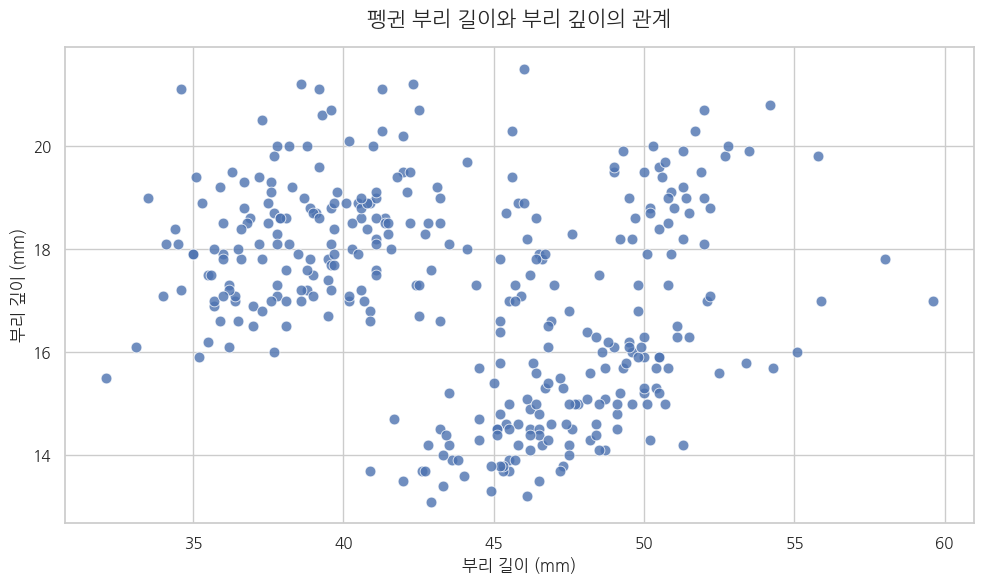

In [7]:
# ─────────────────────────────────────────────
# 문제1: Q1 · 부리 길이 vs 부리 깊이 산점도
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    s=60,          # 점 크기
    alpha=0.8      # 투명도 (겹친 점 구분용)
)

plt.title('펭귄 부리 길이와 부리 깊이의 관계', fontsize=15, pad=15)
plt.xlabel('부리 길이 (mm)', fontsize=12)
plt.ylabel('부리 깊이 (mm)', fontsize=12)

plt.tight_layout()
plt.show()

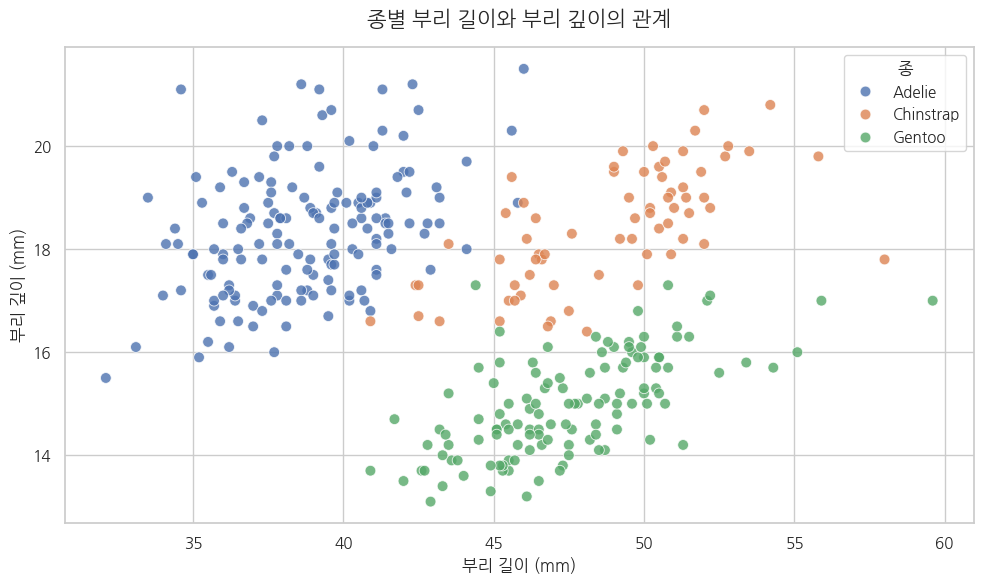

In [9]:
# ─────────────────────────────────────────────
# 문제 1: Q2 · 종별 색상 구분 산점도
# ─────────────────────────────────────────────

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=penguins,
    x='bill_length_mm',
    y='bill_depth_mm',
    hue='species',   # 종별로 색상 구분
    s=60,
    alpha=0.8
)

plt.title('종별 부리 길이와 부리 깊이의 관계', fontsize=15, pad=15)
plt.xlabel('부리 길이 (mm)', fontsize=12)
plt.ylabel('부리 깊이 (mm)', fontsize=12)
plt.legend(title='종')

plt.tight_layout()
plt.show()

In [16]:
# ─────────────────────────────────────────────
# 문제 1: Q3 · 전체 vs 종별 상관계수 비교
# ─────────────────────────────────────────────

# 전체 데이터 상관계수
corr_all = penguins[['bill_length_mm', 'bill_depth_mm']].dropna().corr()
print("[전체] 부리 길이 vs 부리 깊이 상관계수:")
display(corr_all)

# 종별 상관계수
corr_by_species = penguins.groupby('species')[['bill_length_mm', 'bill_depth_mm']].corr()
print("[종별] 부리 길이 vs 부리 깊이 상관계수:")
display(corr_by_species)

# ─────────────────────────────────────────────
# 문제 1: Q3 · 종별 상관계수만 깔끔하게 뽑기
# ─────────────────────────────────────────────

corr_summary = penguins.groupby('species').apply(
    lambda g: g['bill_length_mm'].corr(g['bill_depth_mm'])
)
print("종별 상관계수 (요약):")
display(corr_summary)

print(f"\n전체 상관계수: {corr_all.iloc[0, 1]:.3f}")

[전체] 부리 길이 vs 부리 깊이 상관계수:


,bill_length_mm,bill_depth_mm
bill_length_mm,1.000000,-0.235053
bill_depth_mm,-0.235053,1.000000


[종별] 부리 길이 vs 부리 깊이 상관계수:


bill_length_mm  bill_depth_mm
species                                                
Adelie    bill_length_mm        1.000000       0.391492
          bill_depth_mm         0.391492       1.000000
Chinstrap bill_length_mm        1.000000       0.653536
          bill_depth_mm         0.653536       1.000000
Gentoo    bill_length_mm        1.000000       0.643384
          bill_depth_mm         0.643384       1.000000

종별 상관계수 (요약):


,0
species,
Adelie,0.391492
Chinstrap,0.653536
Gentoo,0.643384



전체 상관계수: -0.235


## 문제 1 정리 — 결과를 말로 설명해 보기

**① Q1의 산점도 방향과 Q3 전체 상관계수의 부호 일치 여부**

Q1(이미지 2)의 산점도는 점들이 전체적으로 왼쪽 위에서 오른쪽 아래로 흩어진 모양, 즉 부리 길이가 길어질수록 깊이가 얕아지는 **음의 방향**으로 보입니다. Q3에서 계산한 전체 상관계수도 **-0.235로 음수**이니, 눈으로 본 방향과 숫자가 정확히 일치합니다.

**② Q3 종별 상관계수, 전체와 부호가 같은가**

전혀 다릅니다. Adelie(0.391), Chinstrap(0.654), Gentoo(0.643) — 세 종 모두 **양수**입니다. 전체는 음수인데 종별로는 셋 다 양수, 부호가 완전히 뒤집혔습니다.

**③ 왜 이런 착시가 생기는가**

Q2(이미지 1)를 보면 이유가 바로 보입니다. 세 종은 각각 **부리 길이 축에서 서로 다른 구간에 자리 잡고** 있습니다.

- Adelie는 왼쪽(35 ~ 46mm 근처)에 몰려 있으면서 깊이는 상대적으로 깊고(17 ~ 21mm)
- Gentoo는 오른쪽(45 ~ 60mm 근처)에 몰려 있으면서 깊이는 상대적으로 얕음(13 ~ 17mm)
- Chinstrap은 그 중간 ~ 오른쪽 구간에 있으면서 깊이는 Adelie와 비슷하게 깊은 편

즉 **종이라는 변수가 부리 길이와도 관련이 있고, 부리 깊이와도 관련이 있는 숨은 공변량(confounder)** 역할을 합니다. 종이 다르면 "부리의 기본 체급"이 통째로 다르게 세팅되는 셈이죠. 그래서:

- **종을 무시하면**: 서로 다른 세 개의 "구름"(종)이 대각선 방향으로 나란히 늘어서 있는 걸 하나의 뭉치로 착각하게 되고, 그 결과 전체를 관통하는 추세선이 실제로는 존재하지 않는 음의 관계처럼 보입니다.
- **종을 고려하면**: 각 구름 안에서는 부리가 길수록 깊이도 함께 커지는, 생물학적으로 자연스러운 양의 관계가 드러납니다.

이건 세 그룹 사이의 "위치 차이(종별 평균 차이)"가 만들어낸 착시일 뿐, 실제 개체 수준의 관계는 그 반대라는 뜻입니다.

**④ '종' 정보가 없었다면 어떤 잘못된 결론을 냈을까**

만약 species 컬럼 자체가 없었다면, 전체 상관계수 -0.235만 보고 "펭귄은 부리가 길수록 깊이가 얕아지는 경향이 있다"는 결론을 내렸을 겁니다. 이는 데이터 전체에서는 통계적으로 맞는 숫자지만, 개체 수준·종 수준의 실제 생물학적 관계와는 **정반대 방향**이라는 점에서 완전히 잘못된 해석입니다.

---

**정리하자면**: 종을 무시하면 "부리 길이와 깊이는 음의 관계"이고, 종을 고려하면 "부리 길이와 깊이는 (각 종 안에서) 양의 관계"입니다. 이게 심슨의 역설이고, 핵심은 **숨은 그룹 변수(confounder)가 두 변수 모두와 관련되어 있을 때 전체 통계량만으로는 진짜 관계를 놓칠 수 있다**는 것입니다.